# Learned forecast correction: model comparison

Three candidate models are trained to predict the t2m forecast error from information available at forecast time, under the evaluation contract defined in notebook 02.

| model | rationale for inclusion |
|---|---|
| ridge regression with harmonic features | interpretable reference; if tree ensembles do not improve on it materially, it is the preferred deployment |
| gradient-boosted trees (XGBoost) | expected to suit a tabular problem of this sample size |
| multilayer perceptron | neural reference point; expected to be data-limited at this sample size |

Feature constraint: every predictor must be available when the application corrects a future forecast step. Admissible inputs are forecast values, station identity and location, calendar and clock variables, and lagged error history through the previous local day. Observed values from the target time are excluded.

Hyperparameter and feature selection use the validation block. The test block is evaluated once, in Section 3.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import common
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

RNG = 7
w = common.wide_pairs()
split = common.SPLIT_V1.label(w.forecast_valid_time)

## 1. Feature construction

Features are defined in `common.build_features`, shared with notebook 04 so that both use an identical definition.

`stn_err_7d` is the station mean error over the trailing seven completed local days, shifted by one day so that no row uses information from its own day. It provides the persistent component of station bias that the same-day scheme reconstructs from scratch each morning, and it is available at 00 local time, when the same-day scheme has no data.

In [2]:
# Shared with notebook 04 - single source of truth in common.py
# (feature rationale in the markdown above and in the function's docstring)
build_features = common.build_features

X = build_features(w)
y = w.err_t2m
tr, va, te = (split=="train").to_numpy(), (split=="valid").to_numpy(), (split=="test").to_numpy()
X.describe().T.round(2)[["mean","std","min","max"]]

,mean,std,min,max
fcst_t2m,24.33,6.07,2.49,44.75
dewpoint_dep,9.30,7.66,-0.07,47.24
lat,38.09,5.44,25.80,48.79
lon,-94.04,15.10,-123.21,-68.83
hour_sin,0.14,0.67,-1.00,1.00
hour_cos,0.11,0.72,-1.00,1.00
doy_sin,-0.65,0.19,-0.87,-0.23
doy_cos,-0.72,0.15,-0.97,-0.49
lead_h,3.23,2.26,0.00,14.00
stn_err_7d,0.26,1.27,-3.43,6.73


## 2. Fitting and model selection

Small hyperparameter grids are used. With a single season of data, a larger search would fit the validation block. XGBoost uses early stopping against the validation block.

Station identity enters the tree models through latitude, longitude, and `stn_err_7d` rather than as a 164-level categorical variable. This is what permits the spatial generalization test in Section 5.

In [3]:
models = {}

models["ridge_harmonic"] = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X[tr], y[tr])

grid, best = [(3,0.05),(5,0.05),(5,0.1),(7,0.05)], None
for depth, lr in grid:
    m = xgb.XGBRegressor(n_estimators=2000, max_depth=depth, learning_rate=lr,
                         subsample=0.8, colsample_bytree=0.8, random_state=RNG,
                         early_stopping_rounds=50, verbosity=0)
    m.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], verbose=False)
    r = common.rmse(y[va] - m.predict(X[va]))
    print(f"  depth={depth} lr={lr}: valid rmse {r:.3f} ({m.best_iteration+1} trees)")
    if best is None or r < best[0]: best = (r, m)
models["xgboost"] = best[1]

models["mlp"] = make_pipeline(StandardScaler(), MLPRegressor(
    hidden_layer_sizes=(64,32), max_iter=400, early_stopping=True,
    n_iter_no_change=20, random_state=RNG)).fit(X[tr], y[tr])
print("fitted:", list(models))

  depth=3 lr=0.05: valid rmse 1.614 (253 trees)


  depth=5 lr=0.05: valid rmse 1.600 (123 trees)


  depth=5 lr=0.1: valid rmse 1.603 (57 trees)


  depth=7 lr=0.05: valid rmse 1.590 (74 trees)


fitted: ['ridge_harmonic', 'xgboost', 'mlp']


## 3. Test-block evaluation

Models and the notebook 02 baselines, evaluated on the same block with the same metric. This is the single evaluation of the test block.

In [4]:
preds = common.baseline_predictions(w, split)
for name, m in models.items():
    preds[name] = m.predict(X)
tbl = common.score_table(w, split, preds, block="test")
tbl

,rmse,mae,bias,n
method,,,,
mlp,2.422,1.913,0.229,12881
global_offset,2.286,1.720,-0.381,12881
raw,2.255,1.691,-0.041,12881
same_day,2.151,1.623,-0.026,12881
station_offset,2.031,1.507,-0.360,12881
ridge_harmonic,1.785,1.319,-0.220,12881
xgboost,1.612,1.184,0.113,12881


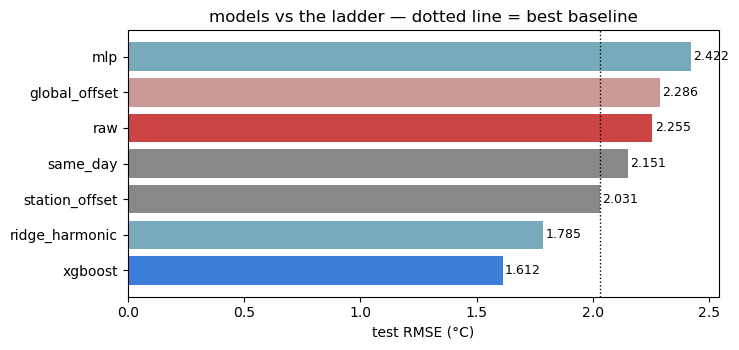

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ts = tbl.sort_values("rmse")
cols = {"raw":"#c44","global_offset":"#c99","same_day":"#888","station_offset":"#888",
        "ridge_harmonic":"#7ab","xgboost":"#3b7dd8","mlp":"#7ab"}
ax.barh(ts.index, ts.rmse, color=[cols.get(i,"#3b7dd8") for i in ts.index])
for yy, v in enumerate(ts.rmse): ax.text(v+0.01, yy, f"{v:.3f}", va="center", fontsize=9)
best_bl = tbl.loc[["station_offset","same_day"]].rmse.min()
ax.axvline(best_bl, color="k", ls=":", lw=1)
ax.set_xlabel("test RMSE (°C)"); ax.set_title("models vs the ladder — dotted line = best baseline")
plt.tight_layout(); plt.show()

## 4. Skill attribution

Feature importance by gain, predicted against actual error on the test block, and the per-station difference in mean absolute error between the tree model and the per-station offset.

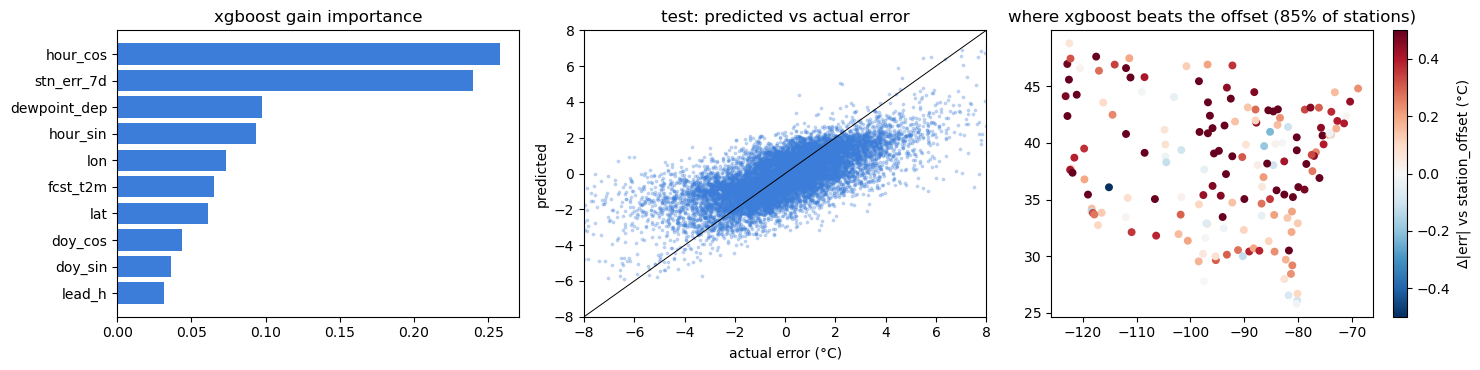

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
bst = models["xgboost"]
imp = pd.Series(bst.feature_importances_, index=X.columns).sort_values()
axes[0].barh(imp.index, imp.values, color="#3b7dd8"); axes[0].set_title("xgboost gain importance")

m_ = te
axes[1].scatter(y[m_], preds.xgboost[m_], s=3, alpha=.25, color="#3b7dd8")
lim = [-8, 8]; axes[1].plot(lim, lim, "k-", lw=.7); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("actual error (°C)"); axes[1].set_ylabel("predicted"); axes[1].set_title("test: predicted vs actual error")

sb = (w[m_].assign(imp=(np.abs(y[m_] - preds.station_offset[m_]) - np.abs(y[m_] - preds.xgboost[m_])))
      .groupby("station_id").agg(imp=("imp","mean"), lat=("lat","first"), lon=("lon","first")))
sc = axes[2].scatter(sb.lon, sb.lat, c=sb.imp, cmap="RdBu_r", vmin=-.5, vmax=.5, s=22)
plt.colorbar(sc, ax=axes[2], label="Δ|err| vs station_offset (°C)")
axes[2].set_title(f"where xgboost beats the offset ({(sb.imp>0).mean():.0%} of stations)")
plt.tight_layout(); plt.show()

## 5. Spatial generalization

The application requires the model only at stations present in training. The DA design (tier 3) applies the same correction at all ASOS sites, including sites with no history. To test that case, the model is refitted with approximately 20% of stations withheld by deterministic hash (`common.is_withheld`) and scored only at those stations.

At unseen stations, `station_offset` reduces to the global offset by construction. That contrast is the quantity of interest in this section.

In [7]:
wh = w.station_id.map(common.is_withheld).to_numpy()
print(f"withheld stations: {w.station_id[wh].nunique()} of {w.station_id.nunique()}")
m2 = xgb.XGBRegressor(**{k: getattr(models['xgboost'], k) for k in
     ["max_depth","learning_rate","subsample","colsample_bytree","random_state"]},
     n_estimators=2000, early_stopping_rounds=50, verbosity=0)
m2.fit(X[tr & ~wh], y[tr & ~wh], eval_set=[(X[va & ~wh], y[va & ~wh])], verbose=False)

mt = te & wh
rows = {"raw": common.rmse(y[mt]),
        "global_offset (what station_offset becomes here)": common.rmse(y[mt] - y[tr & ~wh].mean()),
        "xgboost (never saw these stations)": common.rmse(y[mt] - m2.predict(X[mt]))}
pd.Series(rows, name="test RMSE at withheld stations (°C)").round(3).to_frame()

withheld stations: 35 of 164


,test RMSE at withheld stations (°C)
raw,2.375
global_offset (what station_offset becomes here),2.404
xgboost (never saw these stations),1.850


## 6. Prediction intervals

The application displays a 95% prediction band (`pi95_halfwidth` in `bias.py`). The corresponding quantity here is XGBoost quantile regression at the 2.5% and 97.5% levels. The diagnostic is empirical coverage on the test block, defined as the fraction of observed errors falling inside the predicted band, which should approach 0.95.

In [8]:
qm = {}
for q in (0.025, 0.975):
    qm[q] = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=q,
        n_estimators=500, max_depth=models["xgboost"].max_depth,
        learning_rate=0.05, subsample=0.8, random_state=RNG, verbosity=0)
    qm[q].fit(X[tr], y[tr])
lo, hi = qm[0.025].predict(X[te]), qm[0.975].predict(X[te])
cover = float(((y[te] >= lo) & (y[te] <= hi)).mean())
width = float((hi - lo).mean())
print(f"nominal 95% band -> empirical coverage {cover:.1%}, mean width {width:.2f}°C")
app_width = 2 * 1.96 * y[tr].std()
print(f"(a flat ±1.96σ band from train residuals would be {app_width:.2f}°C wide)")

nominal 95% band -> empirical coverage 79.7%, mean width 4.02°C
(a flat ±1.96σ band from train residuals would be 8.52°C wide)


## 7. Artifacts

The selected point model and the two quantile models are written as JSON rather than pickled, so that they survive library upgrades, remain diffable, and can be loaded by an inference module without a scikit-learn dependency. A metrics record mirroring the Section 3 table is written alongside, so that downstream comparisons are functions of saved artifacts rather than of a rerun.

In [9]:
import json
common.ARTIFACTS.mkdir(exist_ok=True)
models["xgboost"].save_model(common.ARTIFACTS / "t2m_correction_xgb.json")
qm[0.025].save_model(common.ARTIFACTS / "t2m_correction_q025.json")
qm[0.975].save_model(common.ARTIFACTS / "t2m_correction_q975.json")
(common.ARTIFACTS / "t2m_correction_metrics.json").write_text(json.dumps({
    "split": common.SPLIT_V1.name, "features": list(X.columns),
    "test": tbl.reset_index().to_dict("records"),
    "pi95": {"coverage": cover, "mean_width_C": width},
}, indent=2, default=str))
sorted(p.name for p in common.ARTIFACTS.iterdir())

['forecast_obs_pairs.parquet',
 't2m_correction_metrics.json',
 't2m_correction_q025.json',
 't2m_correction_q975.json',
 't2m_correction_xgb.json']

## Summary

Test-block results (split V1, n = 12,881):

| method | test RMSE (°C) |
|---|---|
| mlp | 2.422 |
| global_offset | 2.286 |
| raw | 2.255 |
| same_day | 2.151 |
| station_offset | 2.031 |
| ridge_harmonic | 1.785 |
| xgboost | 1.612 |

1. XGBoost reaches 1.612 °C, 28% below raw GFS (2.255) and 21% below `station_offset` (2.031), the strongest baseline. It also improves on the deployed same-day scheme (2.151) while acting on 100% of rows rather than 66%.
2. Ridge regression with harmonic features reaches 1.785 °C, itself below every baseline. If an interpretable model were required, it would meet the deployment conditions from notebook 02.
3. The multilayer perceptron reaches 2.422 °C, above raw GFS. This is the expected result for a tabular problem with approximately 20,000 training rows, and it is reported because model-class selection should be supported by measurement.
4. Spatial generalization holds: at 35 withheld stations the model reaches 1.850 °C against 2.375 °C raw, indicating that the (latitude, longitude, trailing error) representation transfers to unseen sites. This is the property required by the DA tier-3 application.
5. The prediction interval is not suitable for deployment. The nominal 95% quantile band achieves 79.7% empirical coverage. Its mean width is 4.02 °C against 8.52 °C for a flat 1.96-sigma band computed from training residuals, but under-coverage disqualifies it for display. Conformal calibration on the validation block is the planned correction.

Conditions for deployment, in order: calibrate the interval; extract `common.build_features` and the artifacts into `src/heat/` with unit tests enforcing the causality constraints from Section 1; log corrections in the refresh workflow and score them against arriving observations before any user-facing change.

Scope limits from notebook 01 apply: forecast lead at or below 8 h, warm season, one summer of data.